# Why Do We Use Activation Functions?

Activation functions are a fundamental component of neural networks. Without them, a neural network—regardless of how many layers it has—would behave exactly like a single linear regression model. They introduce the **non-linearity** required to learn complex patterns and approximate any function.

## 1. The Problem with Linear Transformations

Consider a neuron with input vector $x$, weights $W$, and bias $b$. The output $y$ of this neuron without an activation function is simply a linear transformation:

$$y = Wx + b$$

If we stack multiple layers without activation functions, the output of layer $l$ becomes the input to layer $l+1$. Let's calculate the output of a 2-layer network:

$$h_1 = W_1 x + b_1$$
$$y = W_2 h_1 + b_2$$

Substituting $h_1$ into the second equation:

$$y = W_2 (W_1 x + b_1) + b_2$$
$$y = (W_2 W_1) x + (W_2 b_1 + b_2)$$

Let $W_{new} = W_2 W_1$ and $b_{new} = W_2 b_1 + b_2$. The equation simplifies to:

$$y = W_{new} x + b_{new}$$

**Conclusion:** No matter how many layers you stack, a composition of linear functions is still a linear function. The network cannot learn curves, boundaries, or complex interactions between features. It can only solve linearly separable problems.

## 2. Introducing Non-Linearity

To solve complex problems (like image classification or natural language processing), we need the model to learn non-linear decision boundaries. We achieve this by applying a non-linear function $\sigma(\cdot)$ to the output of each neuron:

$$h = \sigma(Wx + b)$$

Because $\sigma$ is non-linear, the composition of layers is no longer equivalent to a single linear transformation. This allows the neural network to approximate highly complex mathematical functions.

## 3. Universal Approximation Theorem

The theoretical power of activation functions is backed by the **Universal Approximation Theorem**. This theorem states that a feed-forward network with a single hidden layer containing a finite number of neurons can approximate continuous functions on compact subsets of $\mathbb{R}^n$, under mild assumptions on the activation function.

Essentially, **as long as the activation function is non-linear (and not a polynomial), the network can learn to map any input to any output** given enough neurons.

## 4. Mathematical Properties of Activation Functions

Different activation functions offer different mathematical properties that affect training and performance:

### A. Differentiability
For a network to learn via **Gradient Descent** and **Backpropagation**, the activation function must be differentiable (or at least sub-differentiable). We calculate the gradient of the loss function with respect to the weights using the chain rule:

$$\frac{\partial L}{\partial W} = \frac{\partial L}{\partial y} \cdot \frac{\partial y}{\partial z} \cdot \frac{\partial z}{\partial W}$$

Where $z = Wx + b$ and $y = \sigma(z)$. The term $\frac{\partial y}{\partial z} = \sigma'(z)$ is the derivative of the activation function. If $\sigma'(z)$ is zero everywhere or undefined, the weights cannot be updated.

### B. Bounded vs. Unbounded Outputs
*   **Bounded (e.g., Sigmoid, Tanh):** Outputs are squashed between a specific range (e.g., $[0, 1]$). This is useful for probability outputs but can lead to **vanishing gradients** because $\sigma'(z)$ becomes very small for large inputs.
*   **Unbounded (e.g., ReLU):** Outputs can go to infinity. This helps mitigate the vanishing gradient problem but can lead to "exploding gradients" if not managed.

### C. Sparsity (e.g., ReLU)
The Rectified Linear Unit (ReLU) is defined as $\sigma(z) = \max(0, z)$.
Mathematically, for any negative input $z < 0$, the output is exactly 0. This means that for any given input, only a subset of neurons actually "fire" (produce a non-zero output). This sparse representation makes the network computationally efficient and less prone to overfitting.

## Summary
We use activation functions to:
1.  **Break the linearity** of deep networks, allowing them to learn complex mappings.
2.  **Enable backpropagation** by providing differentiable paths for gradient flow.
3.  **Map inputs to desired ranges** (e.g., probabilities between 0 and 1).
4.  **Control neuron activity** (e.g., turning off neurons via ReLU) for computational efficiency.

In [61]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 1000)


In [62]:
def plot_function(x, y, name):
        plt.figure(figsize=(10, 5))
        plt.plot(x, y, label=name, linewidth=2)

        plt.title("Activation Functions Comparison")
        plt.xlabel("Input (x)")
        plt.ylabel("Output")
        plt.legend()
        plt.grid(True)
        plt.show()

# Activation Functions & Their Plots

1. Sigmoid:
$$
\operatorname{sigmoid}(x) = \frac{1}{1 + \exp(-x)}
$$

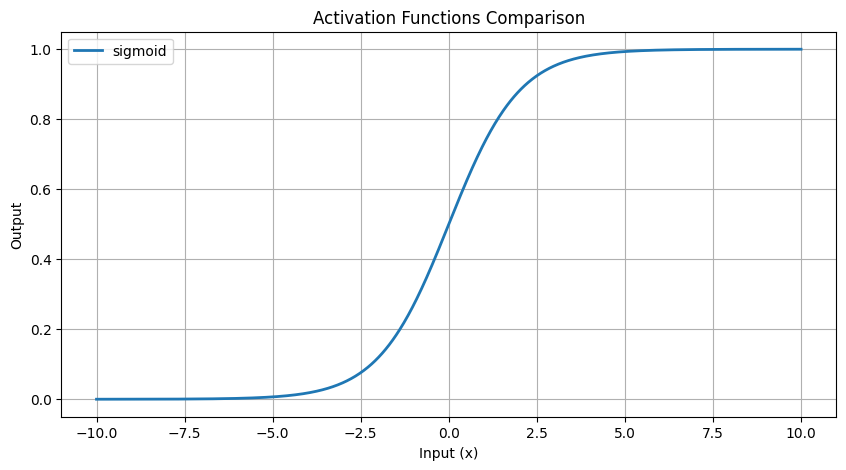

In [63]:
def Sigmoid(x=x):
    return 1 / (1 + np.exp(-x))
plot_function(x, Sigmoid(x), name="sigmoid")

2. Softmax: $$\operatorname{softmax}(\mathbf X)_{ij} = \frac{\exp(\mathbf X_{ij})}{\sum_k \exp \mathbf X_{ik})}.$$

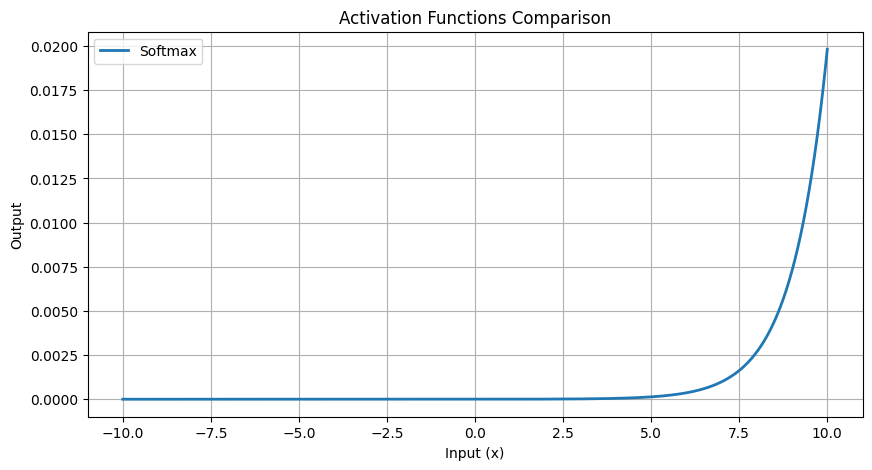

In [70]:
def Softmax(x=x):
    return np.exp(x) / np.sum(np.exp(x))
plot_function(x, Softmax(x), name="Softmax")

3. Tanh (Hyperbolic Tangent):
$$
\operatorname{tanh}(x) = \frac{\sinh(x)}{\cosh(x)} = \frac{\exp(x) - \exp(-x)}{\exp(x) + \exp(-x)}
$$


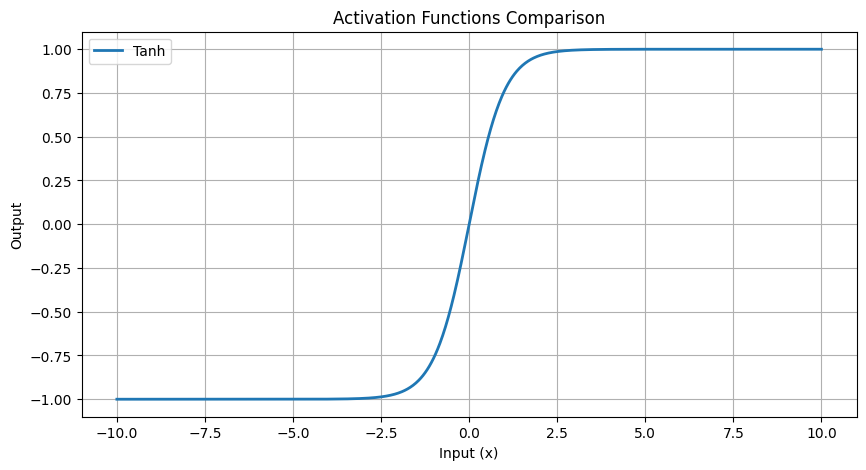

In [65]:
def Tanh(x=x):
    return (np.exp(x) - np.exp(-x))/(np.exp(x) + np.exp(-x))
plot_function(x, Tanh(x), name="Tanh")

4. ReLU: $$\operatorname{ReLU}(x) = \max(0, x)$$


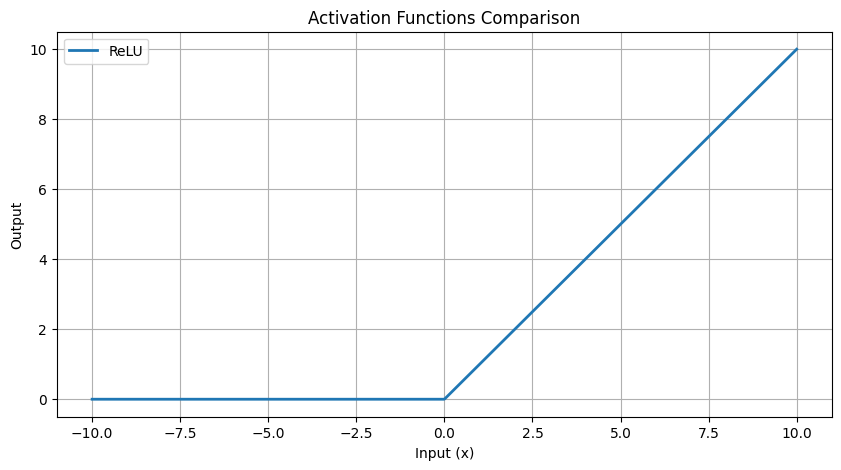

In [66]:
def ReLU(x=x):
    return np.where(x > 0, x, 0)
plot_function(x, ReLU(x), name="ReLU")

5. Leaky ReLU:
$$
\operatorname{LeakyReLU}(x) =
\begin{cases}
x & \text{if } x \geq 0 \\
\alpha x & \text{if } x < 0
\end{cases}
$$
where \( $\alpha$ \) is a small constant (e.g., 0.01).

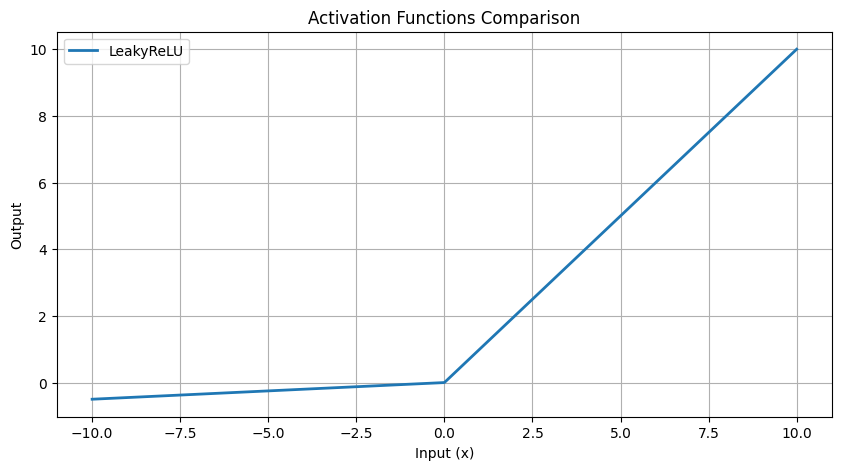

In [67]:
def LeakyReLU(x=x):
    return np.where(x > 0, x, 0.05 * x)
plot_function(x, LeakyReLU(x), name="LeakyReLU")

6. ELU (Exponential Linear Unit):
$$
\operatorname{ELU}(x) =
\begin{cases}
x & \text{if } x > 0 \\
\alpha (\exp(x) - 1) & \text{if } x \leq 0
\end{cases}
$$
where ($\alpha$) is a positive constant.

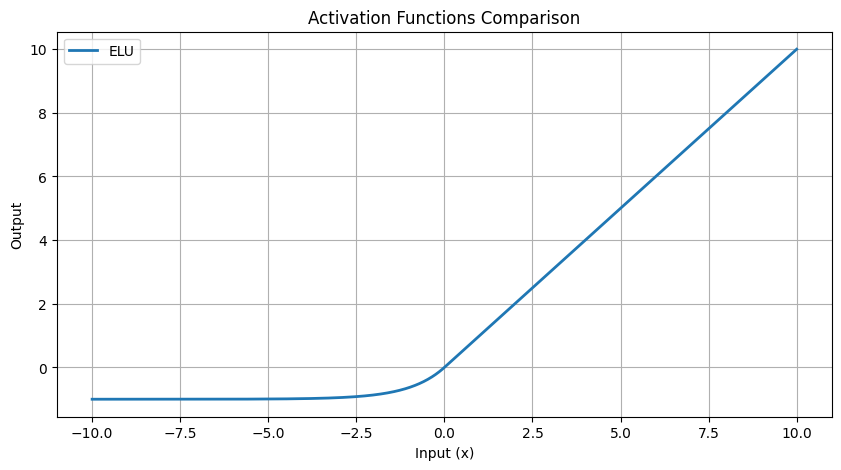

In [68]:
def ELU(x=x):
    return np.where(x > 0, x, 1 * (np.exp(x) - 1))
plot_function(x, ELU(x), name="ELU")

7. SELU (Scaled Exponential Linear Unit):
$$
\operatorname{SELU}(x) =
\lambda
\begin{cases}
x & \text{if } x > 0 \\
\alpha (\exp(x) - 1) & \text{if } x \leq 0
\end{cases}
$$
where \( $\lambda$ \) and \( $\alpha$ \) are predefined constants, typically \( $\lambda \approx 1.0507$ \) and \( $\alpha \approx 1.67326$ \).

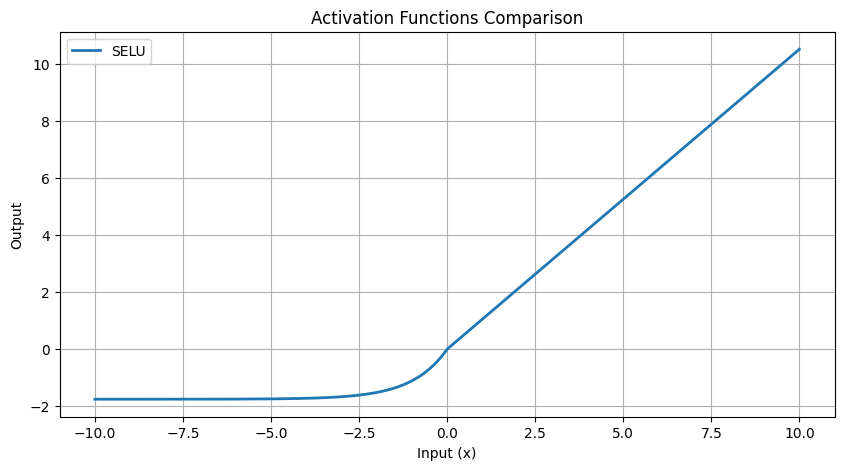

In [69]:
def SELU(x=x):
    return np.where(x > 0, 1.05*x, 1.05*1.67 * (np.exp(x) - 1))
plot_function(x, SELU(x), name="SELU")